In [1]:
# Window
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))
display(HTML("<style>.output_result { width:90% !important; }</style>"))

<div class="alert alert-block alert-danger">
These notebooks are better visualized using codefolding from Jupyter
    <a href=\"https://jupyter-contrib-nbextensions.readthedocs.io/en/latest/\">extensions</a>.
</div>

In [1]:
# Basic everyday packages
import time
import numpy  as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
plt.style.use('ggplot')
rcParams.update({"text.usetex": False, "font.family": "serif", "mathtext.fontset": "cm", "axes.formatter.use_mathtext": True,"axes.unicode_minus": True,})

In [2]:
from scipy.special import spence

In [3]:
import mpmath as mp
mp.dps = 2*50 + 30
mp.mp.dps = 2*50 + 30
print(mp.mp)

# Basic constants
n_0 = mp.mpf('0.0');    n_1 = mp.mpf('1.0');    n_2 = mp.mpf('2.0');    n_4 = mp.mpf('4.0')

Mpmath settings:
  mp.prec = 435               [default: 53]
  mp.dps = 130                [default: 15]
  mp.trap_complex = False     [default: False]


$\newcommand{\dif}{\,\mathrm{d}}$
We are interested in computing the following integral:
\begin{align*}
    H(\lambda, \varepsilon) = \int\limits_0^\theta \frac{1}{8\pi} s^2(\theta) \big( 2 \log {s(\theta)} - 1 \big) \dif \theta,
\end{align*}
where for each $\lambda \in [0,1]$ and $\varepsilon >0$, the following relationships hold:
\begin{align*}
    a &= 1 - (1-2\lambda) \varepsilon,
    &
    \theta &= \arccos \left( \frac{1 - a^2 - \varepsilon^2}{2 a \varepsilon} \right),
    &
    s(\theta) &= -a \cos(\theta) + \sqrt{1 - a^2 \sin^2(\theta)},
    \\
    &&
    L(\theta)& = \frac{s^2(\theta) - 1- a^2 }{2a},
    &
    \phi(\theta) &= \frac{1}{2} \arccos L(\theta).
\end{align*}


It can be proven that
\begin{align*}
H(\lambda,\varepsilon) =  \frac{1}{4 \pi} \bigg[
		 \Im \big( \operatorname{Li}_2 (-a e^{2i\phi}) \big)
		 + (1-a^2) \left[ \phi - \frac{1}{2}  \arctan\left(\frac{ a \sin 2\phi}{1 + a \cos 2\phi} \right)  \right]
		+ \frac{a}{2} \big( 2- \log(1+ a^2 +2a\cos 2\phi)  \big)\sin 2\phi \bigg] \Bigg|_{\phi = \phi(\theta) } - \frac{1}{8} (1-a^2).
\end{align*}
Here $\operatorname{Li}_2$ is the dilogarithm function.

There are two branches of interest for $H$.

1. If $a^2 < 1 + \varepsilon^2$, then $\phi(\theta) = \frac{1}{2} \arccos \left( \dfrac{ \varepsilon^2  - 1 - a^2}{ 2 a }  \right) $ and furthermore $\log\big(1+ a^2 +2a \cos 2\phi(\theta) \big) = 2 \log \varepsilon$.

2. If $a^2 \geq 1 + \varepsilon^2$, then $\phi(\theta) = \frac{1}{2} \arccos \left( \dfrac{ (a^2 - 1)^2 }{2 a \varepsilon^2} - \dfrac{1+a^2}{2a}  \right) $ and furthermore $\log\big(1+ a^2 +2a \cos 2\phi(\theta) \big) =  2 \log \dfrac{a^2-1}{\varepsilon}$. 

The branching point can be determined in terms of $\lambda$, since $1−(1−2\lambda)\varepsilon = \sqrt{1 + \varepsilon^2}$ implies $\lambda_x = \frac{ (\varepsilon-1) + \sqrt{1+\varepsilon^2} }{2\varepsilon}$.

In this notebook, we present a stable approximation of $H$ in double precision and compare it against a high-precision variant.

In [4]:
# High-precision version
def H_mp(λ, ε, scale = False):
    
    a  = n_1 - (n_1 - n_2 * λ) * ε                        # Compute a as a point in the range
    λₓ = ((ε - n_1) + mp.sqrt(n_1 + ε*ε)) / (n_2 * ε)     # Breaking point
    
    '''
        Compute ϕ(φ), cos(2ϕ(φ)), and sin(2ϕ(φ))
    '''
    if λ <= λₓ:
        cos2ϕ = (ε*ε - n_1 - a*a) / (n_2 * a)
        ϕ = mp.mpf('0.5') * mp.acos(cos2ϕ)
        sin2ϕ = mp.sin(2 * ϕ)
        # Tackle special cases
        if a == n_1 - ε:                            # λ = 0
            cos2ϕ = -n_1
            sin2ϕ =  n_0
            ϕ = mp.mpf('0.5') * mp.pi
        if a == n_1:                                # λ = ½
            cos2ϕ = (0.5 * ε*ε) -n_1
            ϕ = mp.mpf('0.5') * mp.acos(cos2ϕ)
            sin2ϕ = mp.sin(2 * ϕ)
    else:
        cos2ϕ  = (a*a - n_1)*(a*a - n_1) / (n_2 * a * ε*ε)
        cos2ϕ -= (n_1 + a*a) / (n_2 * a)
        ϕ = mp.mpf('0.5') * mp.acos(cos2ϕ)
        sin2ϕ = mp.sin(n_2 * ϕ)
        # Tackle special cases
        if (a == n_1 + ε) or λ == n_1:
            cos2ϕ = n_1
            sin2ϕ = n_0
            ϕ = n_0
            
    if a == mp.sqrt(n_1 + ε*ε) or λ == ((ε - n_1) + mp.sqrt(n_1 + ε*ε)) / (n_2 * ε):
        cos2ϕ = -n_1/mp.sqrt(n_1 + ε*ε)
        ϕ = mp.mpf('0.5') * mp.acos(cos2ϕ)
        #sin2ϕ = mp.sin(2 * ϕ)
        sin2ϕ = ε/mp.sqrt(n_1 + ε*ε)

    '''
        Compute half G
    '''
    
    # Dilog term
    z   = -a * mp.exp(2j * ϕ)
    T_1 = mp.polylog(2, z).imag if ((a > n_1 - ε) or (a < n_1 + ε)) else n_0
    
    # Angular term
    α = mp.mpf('0.5') * mp.atan2(a * sin2ϕ, n_1 + a * cos2ϕ)
    T_2 = (n_1 - a*a) * (ϕ - α)
    
    # Log term
    if λ <= λₓ:
        T_3 = a * (n_1 - mp.log(ε) ) * sin2ϕ
    else:
        l_a = (a*a - n_1) / ε
        T_3 = a * (n_1 - mp.log(l_a) ) * sin2ϕ
    
    # Collect terms:
    G  = T_1 + T_2 + T_3
    
    '''
        Weight and shift
    '''
    G /= (4 * mp.pi)
    S  = mp.mpf('0.125') * (a*a - n_1)            # Take off G(a,ϕ(0)) which is exact
    
    
    H = G/(ε*ε*2*mp.log(ε)) + S/(ε*ε*2*mp.log(ε)) if scale else G + S
    
    return H
# Compute asymptotic version depending on case
def H_mp_asy(λ, ε, scale = False):
    a  = n_1 - (n_1 - n_2 * λ) * ε                        # Compute a as a point in the range
    λₓ = ((ε - n_1) + mp.sqrt(n_1 + ε*ε)) / (n_2 * ε)     # Breaking point
    
    if λ <= λₓ:
        # Two term series expansion
        h_1 = (n_1 - n_2 * λ) * mp.sqrt(λ * (n_1 - λ)) / ( n_4 * mp.pi )
        h_2 = (n_1 - n_2 * λ) * ( (n_1 - n_2 * λ) * mp.acos(n_1 - n_2 * λ) - mp.mpf('3.0') * mp.sqrt(λ * (n_1 - λ))) / ( n_4 * mp.pi )
        
        H = h_1 + h_2 /(n_2*mp.log(ε)) if scale else h_1 * (ε*ε*n_2*mp.log(ε)) + h_2 * (ε * ε)
    else:
        # Three term series expansion
        h_0 = (mp.polylog(2, -mp.exp(2j * mp.acos(n_2*λ - n_1) ) ).imag + n_4 *(n_2 * λ - n_1) * ( 1 - mp.log(n_4 * λ - n_2) ) * mp.sqrt(λ * (n_1 - λ))) / ( n_4 * mp.pi )
        h_1 = (n_2 * λ - n_1) * ( ( mp.pi - n_2 * mp.acos(n_2*λ - n_1) ) + n_2 *(n_2 * λ - n_1) * ( 1 - mp.log(n_4 * λ - n_2) ) * mp.sqrt(λ * (n_1 - λ))) / ( n_4 * mp.pi )
        h_2 = (n_2 * λ - n_1)**2 * ( mp.pi - (n_2 * λ - n_1) * ( n_1 + n_2 * mp.log(n_4 * λ - n_2) ) * mp.sqrt(λ * (n_1 - λ))) / ( mp.mpf('8.0') * mp.pi )
        
        H = h_0 + h_1 * ε  + h_1 * ε * ε
        
    return H

In [5]:
N = 100                                              # Number of points

ε = mp.mpf('1e-1')                                   # First value test
λₓ = ((ε - n_1) + mp.sqrt(n_1 + ε*ε)) / (n_2 * ε)    # Breaking point of interval

Λ = mp.linspace(n_0, n_1, N)
A = [n_1 - (n_1 - n_2 * λ) * ε  for λ in Λ]

Although we do not show this here, it can be proven that both branches coincide at $\lambda_x$ and the high-precision code displays an error of $5\times 10^{-125}$.

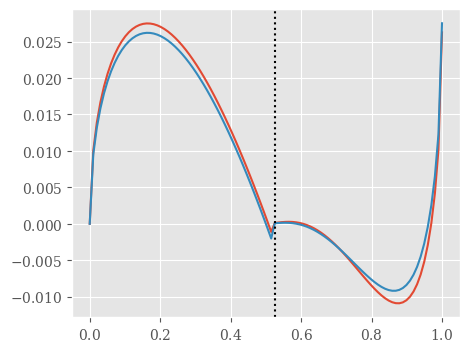

In [6]:
plt.figure(figsize=(5,4))
plt.plot(Λ, [H_mp(λ, ε, True if λ < λₓ else False) for λ in Λ ])
plt.plot(Λ, [H_mp_asy(λ, ε, True if λ < λₓ else False) for λ in Λ ])
plt.axvline(x=λₓ, color='black', linestyle = ':')
plt.plot();

In [7]:
def to_doubled_array(a):
    """
    - If `a` is an np.ndarray: return it unchanged.
    - If `a` is a number: return a 1-D float64 array of length 1.
    - If `a` is a list (or tuple): return it as a NumPy array.
    """
    if isinstance(a, np.ndarray):
        return a
    if np.isscalar(a):
        return np.array([a], dtype=np.float64)
    if isinstance(a, (list, tuple)):
        return np.asarray(a).astype(np.float64)
    raise TypeError(f"Unsupported type: {type(a)!r}")

In [8]:
def sin_2ϕ_stable(a,ε):    
    '''
        First branch: a^2 ≤ 1 + ε^2
    '''
    
    δ = (a - 1.0)/ε
    t_1 = np.clip(1.0 - δ*δ, 0.0, None)                  # 1 - δ^2
    t_2 = np.clip(4.0*a + (δ*δ - 1.0)*ε*ε, 0.0, None)    # (2+δε)^2 - ε^2
    S = (0.5 * ε) * np.sqrt(t_1 * t_2) / a

    '''
        Second branch: a^2 > 1 + ε^2
    '''
    checker = (np.square(a) > 1.0 + ε*ε)
    if checker.any():
        b = a[checker]
        δ = (b - 1.0) / ε
        t_1 = np.clip(1.0 - δ*δ, 0.0, None)                       # = 1 - δ^2
        t_2 = np.clip( 4*b + (δ*δ - 1.0)*ε*ε, 0.0, None)          # = 4a + (δ^2 - 1)ε^2
        n_p = δ * (b + 1.0)
        den = 2.0 * b
        
        S[checker] = n_p * np.sqrt(t_1 * t_2) / den
        
    return S

def H_stable(λ, ε, scale = True, asymp = False):
    """
        Stable H(λ;ε) for small ε, with a in [1-ε, 1+ε].
        Input: 
            - λ is a scalar value or np.array with values in [0,1]
            - ε is a scalar value under 0.5
            - asymp is a logical value, it triggers the use of assymptotic expansions. Should be used for ε < 1e-6
    """
    # Preprocess λ, ε
    λ = to_doubled_array(λ)
    ε = to_doubled_array(ε).item()
    a  = 1.0 - (1.0 - 2.0 * λ) * ε                        # Compute a as a point in the range
    λₓ = ((ε - 1.0) + np.sqrt(1.0 + ε*ε)) / (2.0 * ε)     # Breaking point
    
    if asymp:
        if ε < 1e-15:
            λₓ = 0.5
        
        # Use asymptotic expansion instead of exact formulae
        H   = np.zeros_like(λ)
        λ_L = λ[λ <= λₓ]
        λ_U = λ[λ >  λₓ]
        
        #if λ <= λₓ:
        # Two-term series expansion
        h_1 = 0.25 * (1.0 - 2.0 * λ_L) * np.sqrt(λ_L * (1.0 - λ_L)) / np.pi
        h_2 = 0.25 * (1.0 - 2.0 * λ_L) * ( (1.0 - 2.0 * λ_L) * np.acos(1.0 - 2.0 * λ_L) - 3.0 * np.sqrt(λ_L * (1.0 - λ_L))) / np.pi
        
        H[λ <= λₓ] = h_1 + 0.5 * h_2 /np.log(ε) if scale else h_1 * (2.0 * ε*ε*np.log(ε)) + h_2 * (ε * ε)
        
        #if λ > λₓ:
        # Three-term series expansion
        h_0 = 0.25 * (spence( 1.0 + np.exp(2j * np.acos(2.0 * λ_U - 1.0)) ).imag + 4.0 * (2.0 * λ_U - 1.0) * (1.0 - np.log(4.0 * λ_U - 2.0) ) * np.sqrt(λ_U * (1.0 - λ_U))) / np.pi
        h_1 = 0.25 * (2.0*λ_U - 1.0) * ((np.pi - 2.0 * np.acos(2.0 * λ_U - 1.0)) + 2.0 * (2.0 * λ_U - 1.0) * (1.0 - np.log(4.0 * λ_U - 2.0) ) * np.sqrt(λ_U * (1.0 - λ_U))) / np.pi
        h_2 = 0.125 * (2.0 * λ_U - 1.0)**2 * ( np.pi - (2.0 * λ_U - 1.0) * ( 1.0 + 2.0 * np.log(4.0 * λ_U - 2.0) ) * np.sqrt(λ_U * (1.0 - λ_U))) / np.pi

        H[λ > λₓ] = h_0 + h_1 * ε + h_1 * ε * ε
        
    else:
        # Check values
        np.clip(a, 1.0 - ε, 1.0 + ε, a)

        '''
            Compute ϕ(φ), cos(2ϕ(φ)), and sin(2ϕ(φ))
        '''
        cos2ϕ = 0.5 * (ε*ε - 1.0 - a*a) / a
        checker = (np.square(a) > 1.0 + ε*ε)
        if checker.any():
            b = a[checker]
            c = 2.0 * b * np.square((b - 1.0/b) / (2.0*ε)) - 0.5 * (1.0 + b*b)/b
            cos2ϕ[checker] = c
        np.clip(cos2ϕ, -1.0, 1.0, cos2ϕ)

        ϕ = 0.5 * np.acos(cos2ϕ)

        #sin2ϕ = np.sqrt( np.clip(1.0 - cos2ϕ*cos2ϕ, 0.0, 1.0) )    # Use stable version instead:
        sin2ϕ = sin_2ϕ_stable(a,ε)

        '''
            Compute half G
        '''

        # Dilog term
        T_1 = spence( 1.0 + a * np.exp( 2j * ϕ) ).imag

        # Angular term
        T_2 = (1.0 - a*a) * ( ϕ - 0.5 * np.arctan2(a * sin2ϕ, 1 + a * cos2ϕ) )

        # Log term
        logL = np.full(a.size, 2.0 * np.log(ε))

        if checker.any():
            b = a[checker]
            logL[checker] = 2 * ( np.log( np.abs(b-1.0) ) + np.log(b+1) - np.log(ε) )

        T_3 = a * (1.0 - 0.5 * logL ) * sin2ϕ

        # Collect terms:
        G  = T_1 + T_2 + T_3

        '''
            Weight and shift
        '''
        G *= 0.25/np.pi

        S  = 0.125 * (a*a-1.0)    # Take off G(a,ϕ(0)) which is exact. Alternatives: 0.125 (a-1)(a+1), -0.25(1-a) + 0.125(a-1)^2

        H = G/(ε*ε*2*np.log(ε)) + S/(ε*ε*2*np.log(ε)) if scale else G + S
    
    return H

To test where the approximation should kick in, we perform the following experiment: 
- We evaluate $H$ for $\lambda \in [0,1]$. If $\lambda < \lambda_x$, then we scale $H$ by $\varepsilon^2 \log \varepsilon^2$; we do not scale $H$ otherwise. 
- We evaluate the numerical asymptotic expansion of $H$ with the same scaling rules (black-dashed line).

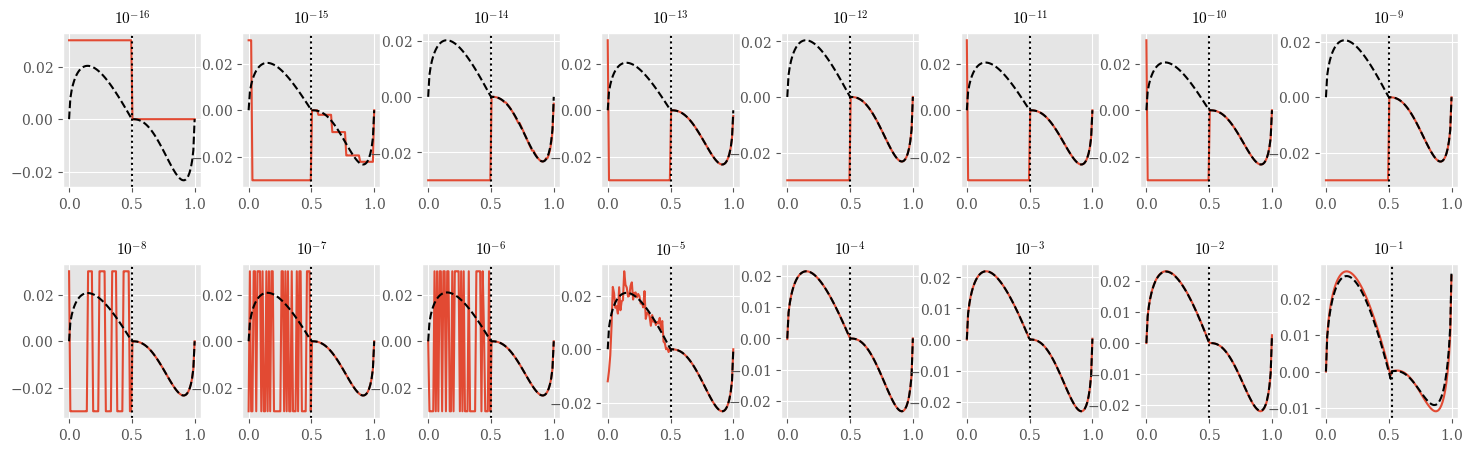

In [9]:
# Test
Λ = mp.linspace(n_0, n_1, N)
Λ_np = np.fromiter((np.float64(x) for x in Λ), dtype=np.float64, count=N)    # NumPy version

nA = np.arange(30,0,-1)[-16:]
E_mp, leg = [mp.mpf('10') ** -a for a in nA], [r'$10^{'+'{0}'.format(-a)+'}$' for a in nA]
E_np = np.fromiter((np.float64(x) for x in E_mp), dtype=np.float64, count=len(E_mp))


fig, ax = plt.subplots(nrows=2, ncols=len(E_mp)//2, figsize = (18,5))
i = 0
for i in range(len(E_mp)):
    ε = E_np[i]

    λₓ = ((ε - n_1) + mp.sqrt(n_1 + ε*ε)) / (n_2 * ε)    # Breaking point of interval
    H_float_no_asy  = np.r_[H_stable(Λ_np[Λ_np <= np.float64(λₓ)], ε, True, False), H_stable(Λ_np[Λ_np > np.float64(λₓ)], ε, False, False)]
    H_float_yes_asy = np.r_[H_stable(Λ_np[Λ_np <= np.float64(λₓ)], ε, True, True), H_stable(Λ_np[Λ_np > np.float64(λₓ)], ε, False, True)]
    
    np.clip(H_float_no_asy, -0.03, 0.03, H_float_no_asy)
    
    ax[i // 8,i % 8].plot(Λ_np, H_float_no_asy)
    ax[i // 8,i % 8].plot(Λ_np, H_float_yes_asy, '--', c='black')
    ax[i // 8,i % 8].set_title(leg[i], {'fontsize':11})
    ax[i // 8,i % 8].axvline(x=λₓ, color='black', linestyle = ':')

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.3, hspace=0.5)

We observe that the asymptotic expansion is needed on the first interval when $\varepsilon < 10^{-4}$. The function is stable for the other interval, but fails already under $\varepsilon < 10^{-13}$. Hence, we can turn on the asymptotic approximation selectively to attain an accurate approximation.

---

We can compare the approximation against the exact values:

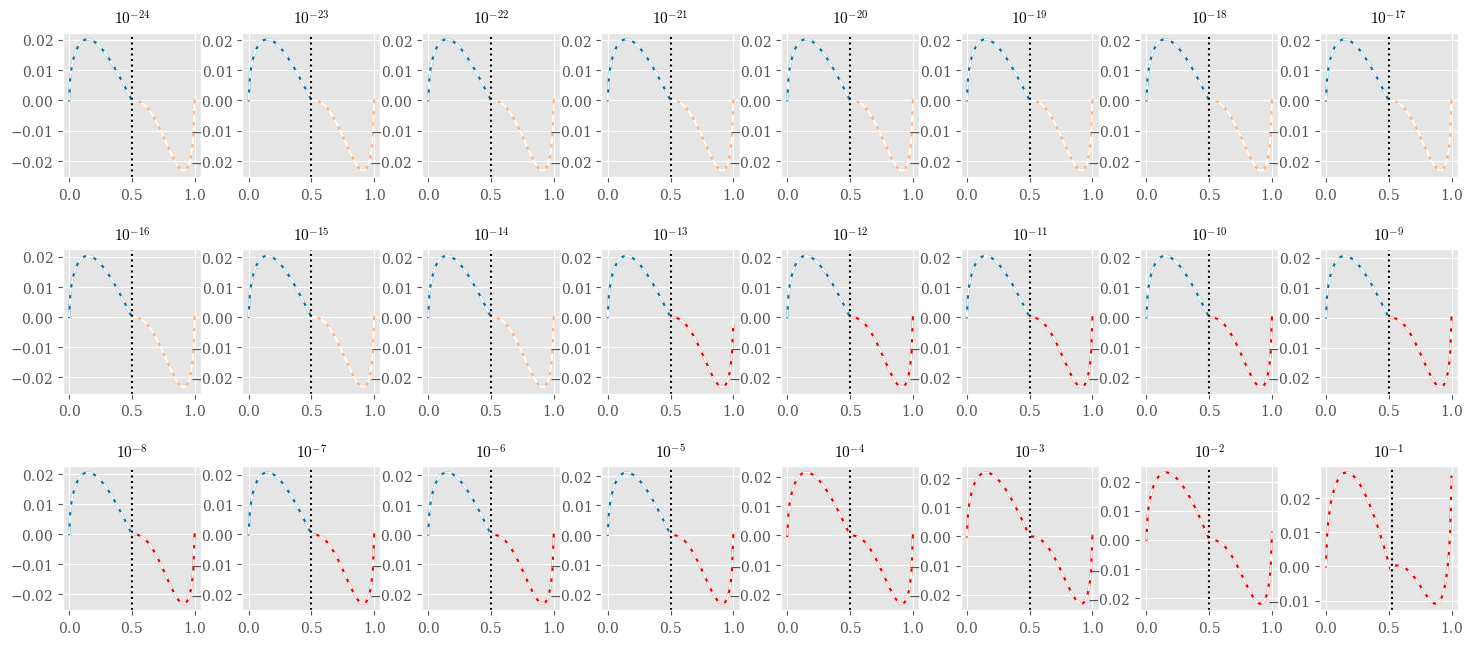

In [10]:
Λ = mp.linspace(n_0, n_1, N)
Λ_np = np.fromiter((np.float64(x) for x in Λ), dtype=np.float64, count=N)    # NumPy version

nA = np.arange(30,0,-1)[-24:]
E_mp, leg = [mp.mpf('10') ** -a for a in nA], [r'$10^{'+'{0}'.format(-a)+'}$' for a in nA]
E_np = np.fromiter((np.float64(x) for x in E_mp), dtype=np.float64, count=len(E_mp))


fig, ax = plt.subplots(nrows=3, ncols=len(E_mp)//3, figsize = (18,7.5))
i = 0
for i in range(len(E_mp)):
    ε = E_np[i]

    λₓ = ((ε - n_1) + mp.sqrt(n_1 + ε*ε)) / (n_2 * ε)    # Breaking point of interval
    if ε < 1e-15:
        λₓ = 0.5
    
    Λ_L = Λ_np[Λ_np <= np.float64(λₓ)]
    Λ_U = Λ_np[Λ_np >  np.float64(λₓ)]
    p_L = True
    p_U = True
    
    if ε >=  1e-4:
        H_1 = H_stable(Λ_L, ε, True, False)
    else:
        H_1 = H_stable(Λ_L, ε, True, True)
        p_L = False
    if ε >=  1e-13:
        H_2 = H_stable(Λ_U, ε, False, False)
    else:
        H_2 = H_stable(Λ_U, ε, False, True)
        p_U = False
    
    #H_float = np.r_[H_1, H_2]
    
    
    ε = E_mp[i]
    λₓ = ((ε - n_1) + mp.sqrt(n_1 + ε*ε)) / (n_2 * ε)
    H_mp_exact = [H_mp(λ, ε, True if λ < λₓ else False) for λ in Λ ]
    
    #ax[i // 8,i % 8].plot(Λ_np, H_float)
    ax[i // 8,i % 8].plot(Λ_L, H_1, c = 'xkcd:red' if p_L else 'xkcd:ocean blue')
    ax[i // 8,i % 8].plot(Λ_U, H_2, c = 'xkcd:red' if p_U else 'xkcd:peach')
    
    ax[i // 8,i % 8].plot(Λ_np, H_mp_exact, '--', c='xkcd:white')
    ax[i // 8,i % 8].set_title(leg[i], {'fontsize':11})
    ax[i // 8,i % 8].axvline(x=λₓ, color='black', linestyle = ':')

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.3, hspace=0.5)

And we can compute errors:

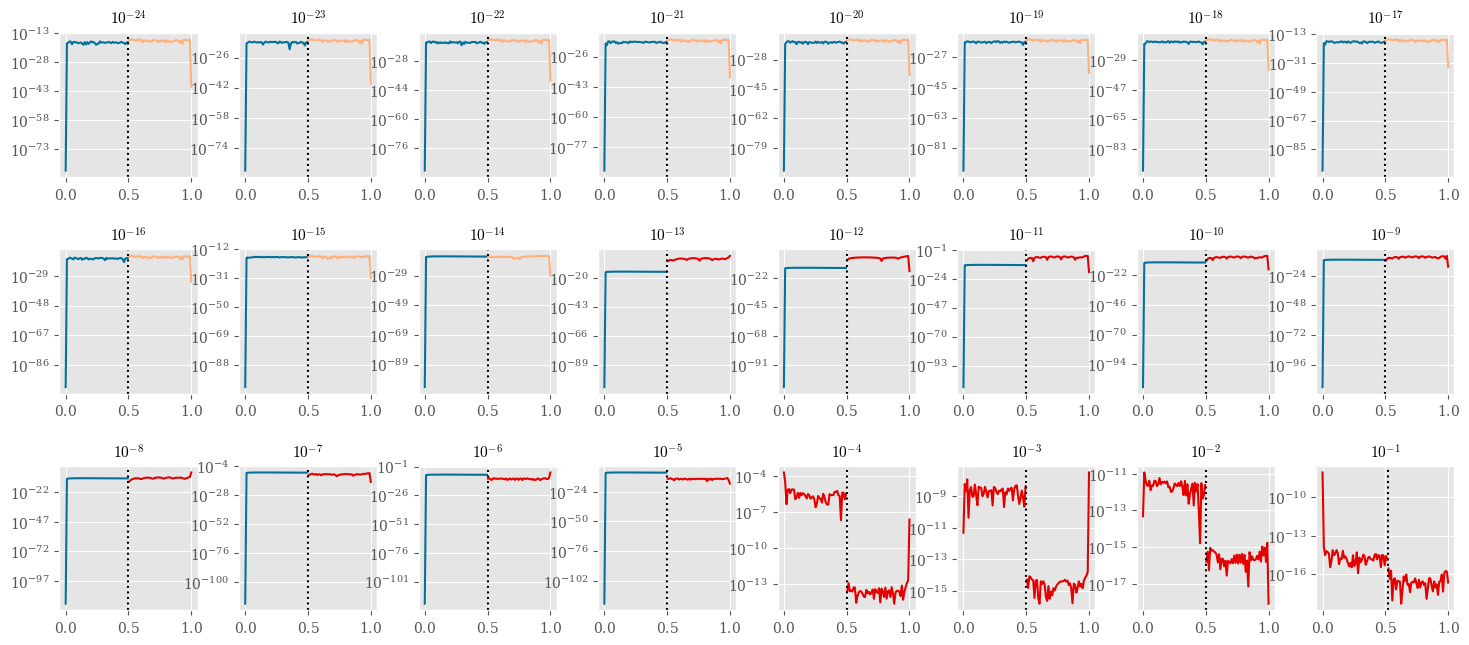

In [11]:
Λ = mp.linspace(n_0, n_1, N)
Λ_np = np.fromiter((np.float64(x) for x in Λ), dtype=np.float64, count=N)    # NumPy version

nA = np.arange(30,0,-1)[-24:]
E_mp, leg = [mp.mpf('10') ** -a for a in nA], [r'$10^{'+'{0}'.format(-a)+'}$' for a in nA]
E_np = np.fromiter((np.float64(x) for x in E_mp), dtype=np.float64, count=len(E_mp))


fig, ax = plt.subplots(nrows=3, ncols=len(E_mp)//3, figsize = (18,7.5))
i = 0
for i in range(len(E_mp)):
    ε = E_np[i]

    λₓ = ((ε - n_1) + mp.sqrt(n_1 + ε*ε)) / (n_2 * ε)    # Breaking point of interval
    if ε < 1e-15:
        λₓ = 0.5
    
    Λ_L = Λ_np[Λ_np <= np.float64(λₓ)]
    Λ_U = Λ_np[Λ_np >  np.float64(λₓ)]
    p_L = True
    p_U = True
    
    if ε >=  1e-4:
        H_1 = H_stable(Λ_L, ε, True, False)
    else:
        H_1 = H_stable(Λ_L, ε, True, True)
        p_L = False
    if ε >=  1e-13:
        H_2 = H_stable(Λ_U, ε, False, False)
    else:
        H_2 = H_stable(Λ_U, ε, False, True)
        p_U = False
    
    #H_float = np.r_[H_1, H_2]
    
    
    ε = E_mp[i]
    λₓ = ((ε - n_1) + mp.sqrt(n_1 + ε*ε)) / (n_2 * ε)
    H_mp_exact = [H_mp(λ, ε, True if λ < λₓ else False) for λ in Λ ]
    
    #ax[i // 8,i % 8].plot(Λ_np, H_float)
    Err_L = abs(np.asarray(H_mp_exact)[Λ_np <= np.float64(λₓ)] - H_1)
    Err_U = abs(np.asarray(H_mp_exact)[Λ_np >  np.float64(λₓ)] - H_2)
    ax[i // 8,i % 8].plot(Λ_L, Err_L, c = 'xkcd:red' if p_L else 'xkcd:ocean blue')
    ax[i // 8,i % 8].plot(Λ_U, Err_U, c = 'xkcd:red' if p_U else 'xkcd:peach')
    
    #ax[i // 8,i % 8].plot(Λ_np, H_mp_exact, '--', c='xkcd:white')
    ax[i // 8,i % 8].set_title(leg[i], {'fontsize':11})
    ax[i // 8,i % 8].axvline(x=λₓ, color='black', linestyle = ':')
    ax[i // 8,i % 8].set_yscale('log')
    #ax[i // 8,i % 8].set_ylim([np.float64(ε/400), None])

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.3, hspace=0.5)

---